# Streamlined MIMIC Experiment Results

Thin notebook for running or viewing the streamlined manuscript experiment artifacts.

In [1]:
# PROFILE selects the YAML config under manuscript/experiments/configs/.
# Options: "smoke" runs a small end-to-end experiment; "full" runs the manuscript-scale grid.
PROFILE = "smoke"

# RUN_EXPERIMENT controls whether this notebook executes experiments or only reloads saved artifacts.
# True: run the selected profile and overwrite generated artifact tables.
# False: view existing CSV artifacts from ARTIFACT_DIR without fitting models or fetching data.
RUN_EXPERIMENT = False

# RESTART controls resumability when RUN_EXPERIMENT=True.
# False: resume from existing raw/condition_results.csv and skip completed conditions.
# True: delete existing raw results first and rerun the selected profile from scratch.
RESTART = False

# SHOW_PROGRESS displays an updating text progress bar while RUN_EXPERIMENT=True.
# It is useful for smoke/full runs; set False if you prefer quieter notebook output.
SHOW_PROGRESS = True

# CONFIG_PATH can point to a custom YAML file. Leave as None to use configs/{PROFILE}.yaml.
CONFIG_PATH = None

# ARTIFACT_DIR controls where raw results, tables, figures, and reports are written/read.
# Leave as None to use manuscript/experiments/artifacts/.
ARTIFACT_DIR = None

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import sys
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 240)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "MIMIC" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPERIMENT_ROOT = PROJECT_ROOT / "manuscript" / "experiments"
for path in [PROJECT_ROOT / "src", EXPERIMENT_ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"Python executable: {sys.executable}")
try:
    import scikit_posthocs
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "scikit-posthocs is required for critical difference diagrams. "
        f"Install it in this notebook kernel with: {sys.executable} -m pip install scikit-posthocs"
    ) from exc

from streamlined.config import artifact_paths, ensure_artifact_dirs, load_config
from streamlined.datasets import dataset_registry
from streamlined.runner import artifact_manifest, run_profile
from streamlined.plotting import plot_critical_difference_diagram, plot_mean_learning_curves, plot_rank_summary

Python executable: /home/fabrizio/.venvs/py314/bin/python


In [4]:
config_path = Path(CONFIG_PATH) if CONFIG_PATH else EXPERIMENT_ROOT / "configs" / f"{PROFILE}.yaml"
artifact_dir = ARTIFACT_DIR or str(EXPERIMENT_ROOT / "artifacts")
config = load_config(config_path, artifact_dir=artifact_dir)
ensure_artifact_dirs(config)
print(f"Artifact directory: {config.artifact_root}")
display(dataset_registry())
manifest = artifact_manifest(config)
display(manifest[["artifact", "relative_path", "exists"]])

Artifact directory: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/MIMIC/manuscript/experiments/artifacts


,key,name,openml_id,target,n_rows,numeric_features,categorical_features,status
0,adult,Adult,1590,class,48842,6,8,ready
1,bank_marketing,Bank Marketing,44234,y,45211,7,9,ready
2,default_credit,Default of Credit Card Clients,42477,y,30000,14,9,ready


,artifact,relative_path,exists
0,raw_results,raw/condition_results.csv,True
1,learning_curves,tables/learning_curves.csv,True
2,aulc,tables/aulc.csv,True
3,pairwise,tables/pairwise_comparisons.csv,True
4,regime,tables/regime_summary.csv,True
5,rank,tables/rank_summary.csv,True
6,conclusions,reports/prescriptive_conclusions.md,True
7,figures,figures,True


In [5]:
tables = run_profile(config, run_experiment=RUN_EXPERIMENT, show_progress=SHOW_PROGRESS, restart=RESTART)
display(tables["raw_results"].head())
display(tables["learning_curves"].head())
display(tables["aulc"].head())
display(tables["pairwise"].head())
display(tables["regime"].head())

,dataset_key,imbalance_ratio,training_size,seed,method,generated_count,real_minority_count,real_majority_count,roc_auc,pr_auc,...,brier,n_samples,n_features,n_numeric_features,n_categorical_features,original_imbalance_ratio,minority_size,preprocessed_dim,missingness_rate,baseline_roc_auc
0,adult,2.0,128,0,real_balanced,0,43,43,0.889991,0.719627,...,0.137004,800,14,6,8,3.188482,191,87,0.009107,0.920429
1,adult,2.0,128,0,direct_smote,43,43,86,0.892628,0.701697,...,0.129438,800,14,6,8,3.188482,191,87,0.009107,0.920429
2,adult,2.0,128,0,direct_displacement,43,43,86,0.901400,0.725744,...,0.130838,800,14,6,8,3.188482,191,87,0.009107,0.920429
3,adult,2.0,128,0,latent_smote,43,43,86,0.901352,0.744112,...,0.128914,800,14,6,8,3.188482,191,87,0.009107,0.920429
4,adult,2.0,128,0,latent_displacement,43,43,86,0.914246,0.749742,...,0.114047,800,14,6,8,3.188482,191,87,0.009107,0.920429


,dataset_key,imbalance_ratio,training_size,method,roc_auc,pr_auc,balanced_accuracy,f1,brier
0,adult,2.0,128,direct_displacement,0.887619,0.675492,0.784800,0.650898,0.141269
1,adult,2.0,128,direct_smote,0.882298,0.675511,0.781493,0.650516,0.140044
2,adult,2.0,128,latent_displacement,0.888242,0.695146,0.776819,0.646774,0.131049
3,adult,2.0,128,latent_smote,0.879110,0.680292,0.769988,0.633290,0.140031
4,adult,2.0,128,real_balanced,0.858906,0.657021,0.781924,0.625541,0.160588


,dataset_key,imbalance_ratio,method,seed,segment,aulc
0,adult,2.0,direct_displacement,0,full,0.909668
1,adult,2.0,direct_displacement,0,early,0.901400
2,adult,2.0,direct_displacement,0,mid,0.909668
3,adult,2.0,direct_displacement,1,full,0.889848
4,adult,2.0,direct_displacement,1,early,0.873838


,dataset_key,imbalance_ratio,segment,left_method,right_method,mean_delta,ci_low,ci_high,n,indistinguishable
0,adult,2.0,early,latent_displacement,latent_smote,0.009131,0.005369,0.012894,2,True
1,adult,2.0,early,direct_displacement,direct_smote,0.005321,0.001869,0.008772,2,True
2,adult,2.0,early,latent_smote,direct_smote,-0.003188,-0.015099,0.008724,2,True
3,adult,2.0,early,latent_displacement,direct_displacement,0.000623,-0.011600,0.012846,2,True
4,adult,2.0,early,direct_smote,real_balanced,0.023392,0.002636,0.044147,2,False


,method,best_segment,best_imbalance_ratio,mean_full_aulc,indistinguishable_from_real
0,real_balanced,full,2.0,0.812061,False
1,direct_smote,full,2.0,0.879805,False
2,direct_displacement,full,2.0,0.879994,False
3,latent_smote,full,2.0,0.876645,False
4,latent_displacement,full,2.0,0.882930,False


Higher ROC AUC is better
Lower rank is better


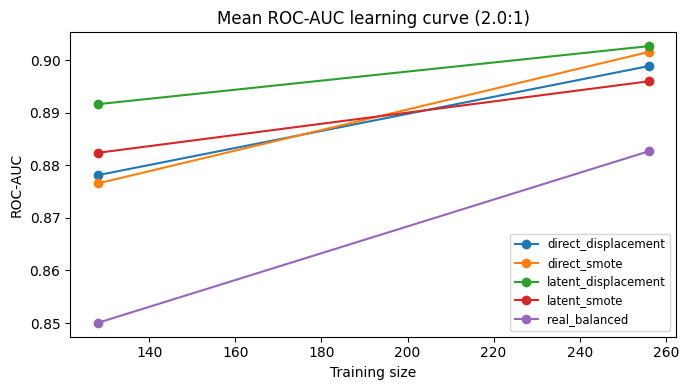

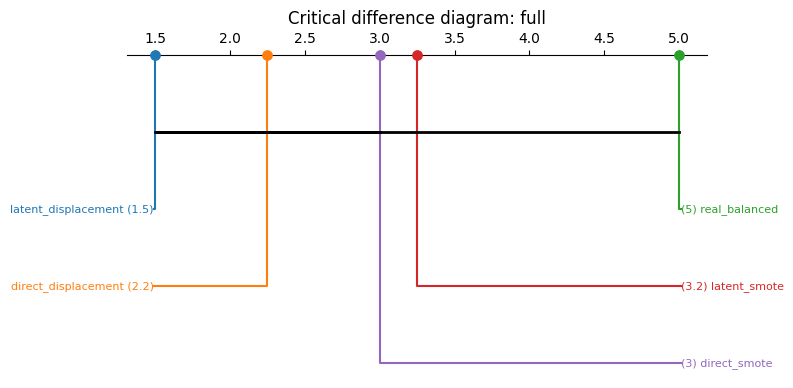

In [ ]:
if not tables["learning_curves"].empty:
    print('Higher ROC AUC is better')
    ratio = sorted(tables["learning_curves"]["imbalance_ratio"].unique())[0]
    fig, ax = plot_mean_learning_curves(tables["learning_curves"], imbalance_ratio=ratio)
    display(fig)
if not tables["aulc"].empty:
    print('Lower rank is better')
    fig, ax = plot_critical_difference_diagram(tables["aulc"], segment="full")
    display(fig)